# Fashion-MNIST exploratory data analysis

Evidence for the dataset description, and for the representation choices that separate the
five model families: flattened pixels (linear, MLP), spatial features (CNN), and row,
column, or patch sequences (LSTM/GRU, Transformer).

In [1]:
import sys

sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision

from src.data import build_dataloaders, load_split, normalization_stats, to_sequence
from src.interfaces import CLASS_NAMES, NUM_CLASSES
from src.utils import load_config, resolve_path, set_seed

config = load_config(resolve_path("configs/base.yaml"))
config["loader"]["num_workers"] = 0
set_seed(config["seed"])

FIGURES = resolve_path("results/eda")
FIGURES.mkdir(parents=True, exist_ok=True)


def save(fig, name):
    fig.tight_layout()
    fig.savefig(FIGURES / f"{name}.png", dpi=200)
    for suffix in ("svg", "pdf"):
        fig.savefig(FIGURES / f"{name}.{suffix}", dpi=300)


data_dir = resolve_path(config["dataset"]["root"])
official_train = torchvision.datasets.FashionMNIST(root=str(data_dir), train=True)
official_test = torchvision.datasets.FashionMNIST(root=str(data_dir), train=False)
split = load_split(resolve_path(config["dataset"]["split_file"]))

train_idx, val_idx = np.array(split["train"]), np.array(split["val"])
pixels = official_train.data.numpy()
labels = official_train.targets.numpy()
test_pixels = official_test.data.numpy()
test_labels = official_test.targets.numpy()

subsets = {
    "train": (pixels[train_idx], labels[train_idx]),
    "val": (pixels[val_idx], labels[val_idx]),
    "test": (test_pixels, test_labels),
}

## Dataset description

In [2]:
print(f"source            {config['dataset']['source']}")
print(f"official sizes    train {len(pixels)}, test {len(test_pixels)}")
print(f"image             {pixels.shape[1]}x{pixels.shape[2]}, 1 channel, {pixels.dtype}, [{pixels.min()}, {pixels.max()}]")
print(f"flattened         {pixels.shape[1] * pixels.shape[2]} features per image")
print(f"classes           {NUM_CLASSES}: {', '.join(CLASS_NAMES)}")
print()
print(f"split file        {config['dataset']['split_file']}")
print(f"split policy      seed {split['seed']}, stratified {split['stratified']}")
for name, (images, _) in subsets.items():
    print(f"  {name:<5} {len(images):>6} images")

source            torchvision.datasets.FashionMNIST
official sizes    train 60000, test 10000
image             28x28, 1 channel, uint8, [0, 255]
flattened         784 features per image
classes           10: T-shirt/top, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle boot

split file        splits/fashion-mnist-seed0.json
split policy      seed 0, stratified True
  train  54000 images
  val     6000 images
  test   10000 images


## Class distribution

The official dataset is balanced, and the stratified split keeps every subset balanced, so
accuracy and macro-F1 are not distorted by class priors.

In [3]:
counts = {name: np.bincount(lbl, minlength=NUM_CLASSES) for name, (_, lbl) in subsets.items()}

print(f"{'class':<14}" + "".join(f"{name:>8}" for name in counts))
for label, name in enumerate(CLASS_NAMES):
    print(f"{name:<14}" + "".join(f"{counts[s][label]:>8}" for s in counts))
print()
for name, count in counts.items():
    print(f"{name:<5} max-to-min ratio {count.max() / count.min():.3f}")

class            train     val    test
T-shirt/top       5400     600    1000
Trouser           5400     600    1000
Pullover          5400     600    1000
Dress             5400     600    1000
Coat              5400     600    1000
Sandal            5400     600    1000
Shirt             5400     600    1000
Sneaker           5400     600    1000
Bag               5400     600    1000
Ankle boot        5400     600    1000

train max-to-min ratio 1.000
val   max-to-min ratio 1.000
test  max-to-min ratio 1.000


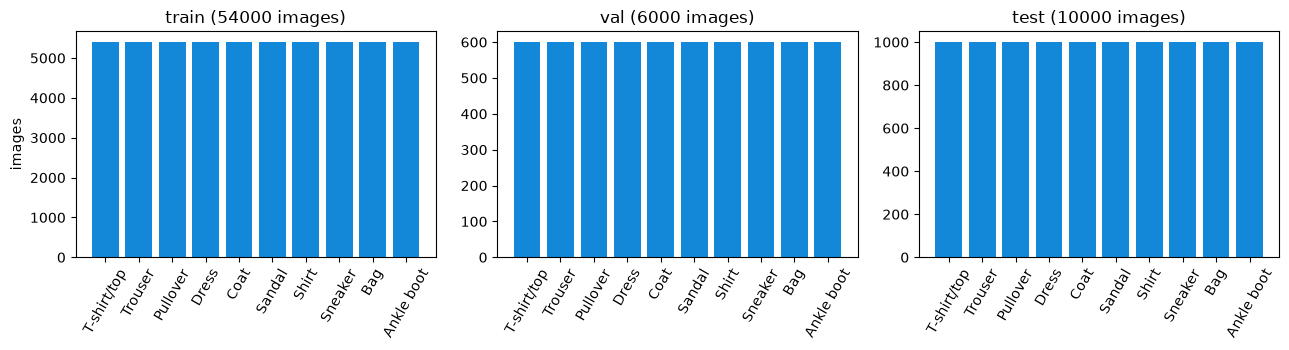

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, (name, count) in zip(axes, counts.items()):
    ax.bar(CLASS_NAMES, count, color="#1488D8")
    ax.set_title(f"{name} ({count.sum()} images)")
    ax.tick_params(axis="x", rotation=60)
axes[0].set_ylabel("images")
save(fig, "class_distribution")
plt.show()

## Samples and class means

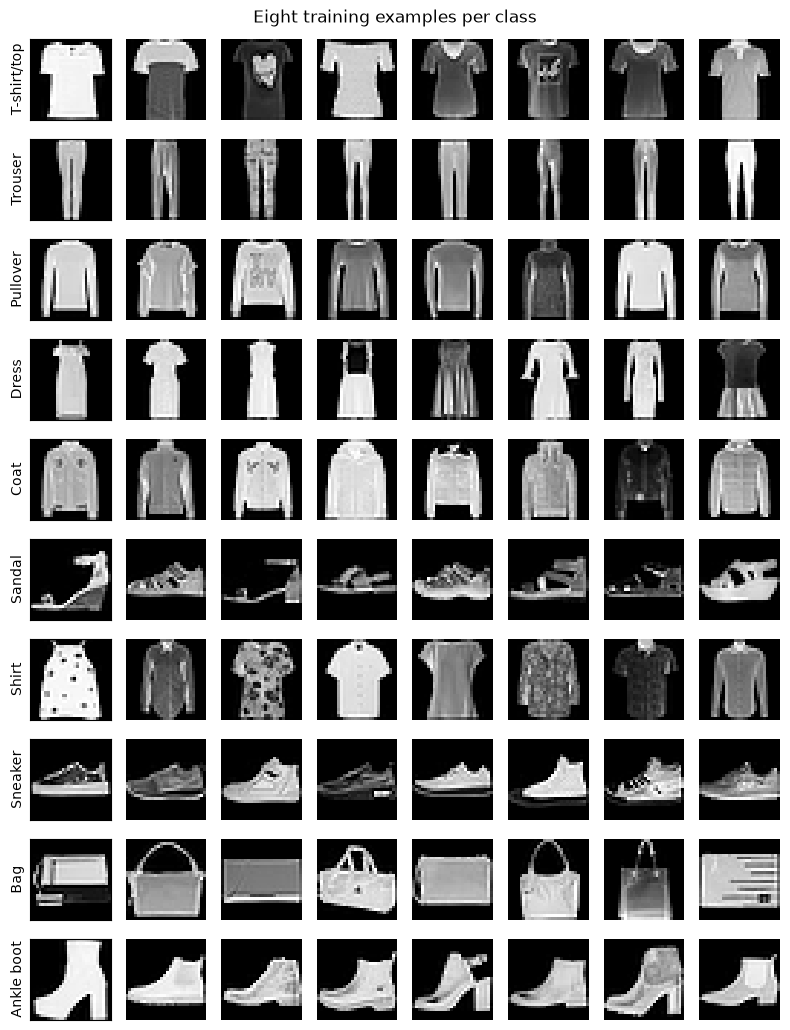

In [5]:
rng = np.random.default_rng(config["seed"])
train_pixels, train_labels = subsets["train"]

fig, axes = plt.subplots(NUM_CLASSES, 8, figsize=(8, 10.5))
for label, row in enumerate(axes):
    picks = rng.choice(np.flatnonzero(train_labels == label), size=8, replace=False)
    for ax, index in zip(row, picks):
        ax.imshow(train_pixels[index], cmap="gray", vmin=0, vmax=255, interpolation="nearest")
        ax.axis("off")
    row[0].set_ylabel(CLASS_NAMES[label])
    row[0].axis("on")
    row[0].set_xticks([])
    row[0].set_yticks([])
fig.suptitle("Eight training examples per class")
save(fig, "sample_grid")
plt.show()

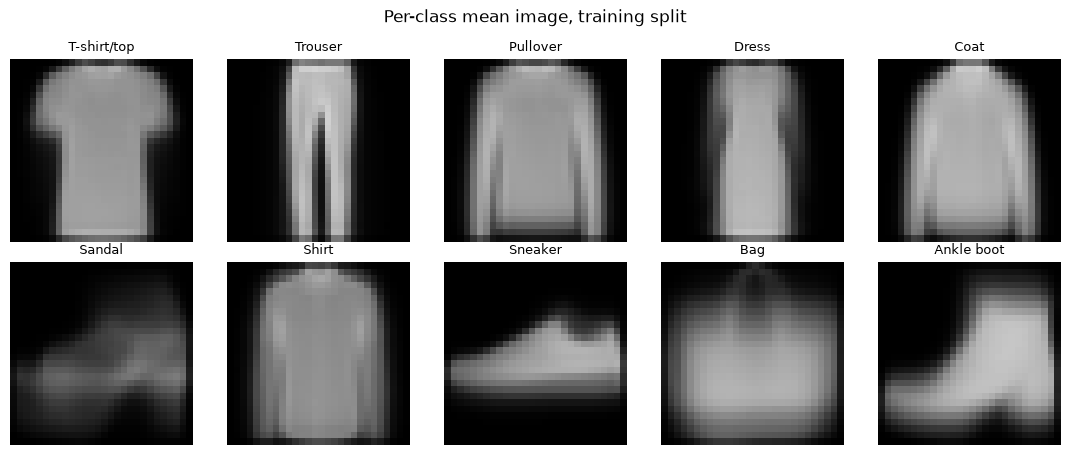

In [6]:
class_means = np.stack([train_pixels[train_labels == label].mean(axis=0) for label in range(NUM_CLASSES)])

fig, axes = plt.subplots(2, 5, figsize=(11, 4.6))
for label, ax in enumerate(axes.flat):
    ax.imshow(class_means[label], cmap="gray", vmin=0, vmax=255, interpolation="nearest")
    ax.set_title(CLASS_NAMES[label], fontsize=9)
    ax.axis("off")
fig.suptitle("Per-class mean image, training split")
save(fig, "class_means")
plt.show()

## Pixel statistics

Most of the frame is background, and the garment sits in the centre, so a large share of the
784 input features carries no signal.

In [7]:
scaled = train_pixels / 255.0
print(f"mean {scaled.mean():.4f}   std {scaled.std():.4f}   zero pixels {(train_pixels == 0).mean():.1%}")
print()
print(f"{'class':<14}{'mean':>8}{'std':>8}{'zeros':>9}")
for label, name in enumerate(CLASS_NAMES):
    subset = train_pixels[train_labels == label] / 255.0
    print(f"{name:<14}{subset.mean():>8.3f}{subset.std():>8.3f}{(subset == 0).mean():>8.1%}")

mean 0.2858   std 0.3529   zero pixels 50.2%

class             mean     std    zeros
T-shirt/top      0.326   0.351   40.5%
Trouser          0.222   0.343   65.2%
Pullover         0.376   0.358   35.1%
Dress            0.258   0.354   57.2%
Coat             0.386   0.377   39.9%
Sandal           0.137   0.263   67.8%
Shirt            0.332   0.339   37.1%
Sneaker          0.168   0.295   66.2%
Bag              0.353   0.365   41.5%
Ankle boot       0.301   0.370   51.6%


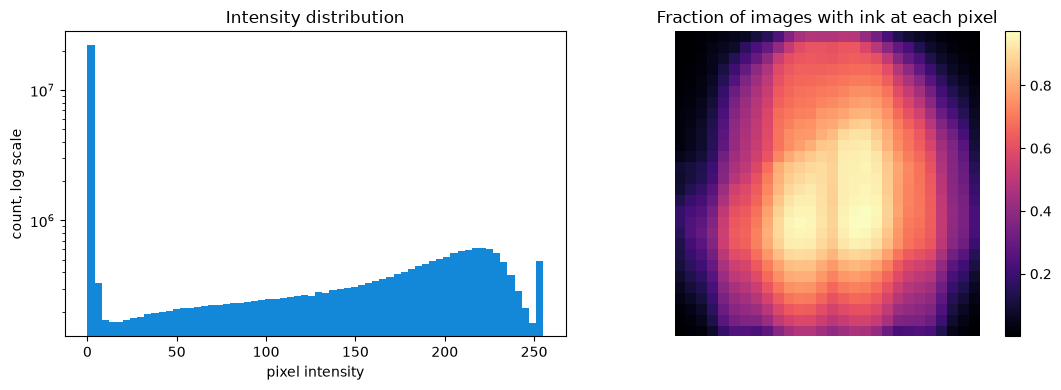

In [8]:
occupancy = (train_pixels > 0).mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(train_pixels.reshape(-1), bins=64, color="#1488D8")
axes[0].set_yscale("log")
axes[0].set_xlabel("pixel intensity")
axes[0].set_ylabel("count, log scale")
axes[0].set_title("Intensity distribution")
image = axes[1].imshow(occupancy, cmap="magma", interpolation="nearest")
axes[1].set_title("Fraction of images with ink at each pixel")
axes[1].axis("off")
fig.colorbar(image, ax=axes[1])
save(fig, "pixel_intensity")
plt.show()

## Class overlap

Cosine similarity between class means, plus a nearest-class-mean classifier on raw pixels.
The classifier is not a submission model; it is a floor that the five required models must
clearly beat, and its errors predict where they will struggle.

In [9]:
flat_means = class_means.reshape(NUM_CLASSES, -1)
unit = flat_means / np.linalg.norm(flat_means, axis=1, keepdims=True)
similarity = unit @ unit.T

pairs = sorted(
    ((similarity[i, j], CLASS_NAMES[i], CLASS_NAMES[j]) for i in range(NUM_CLASSES) for j in range(i + 1, NUM_CLASSES)),
    reverse=True,
)
print("most similar class pairs")
for score, first, second in pairs[:5]:
    print(f"  {first:<14} {second:<14} {score:.4f}")

most similar class pairs
  Coat           Shirt          0.9875
  Pullover       Coat           0.9837
  Pullover       Shirt          0.9830
  T-shirt/top    Shirt          0.9490
  Sandal         Ankle boot     0.9277


In [10]:
val_pixels, val_labels = subsets["val"]
distances = ((val_pixels.reshape(len(val_pixels), 1, -1) - flat_means[None]) ** 2).sum(axis=2)
predictions = distances.argmin(axis=1)
confusion = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=int)
np.add.at(confusion, (val_labels, predictions), 1)

print(f"nearest-class-mean accuracy on val: {(predictions == val_labels).mean():.3f}")
print()
print(f"{'class':<14}{'recall':>8}")
for label, name in enumerate(CLASS_NAMES):
    print(f"{name:<14}{confusion[label, label] / confusion[label].sum():>8.3f}")

nearest-class-mean accuracy on val: 0.684

class           recall
T-shirt/top      0.707
Trouser          0.860
Pullover         0.462
Dress            0.815
Coat             0.553
Sandal           0.772
Shirt            0.220
Sneaker          0.797
Bag              0.783
Ankle boot       0.872


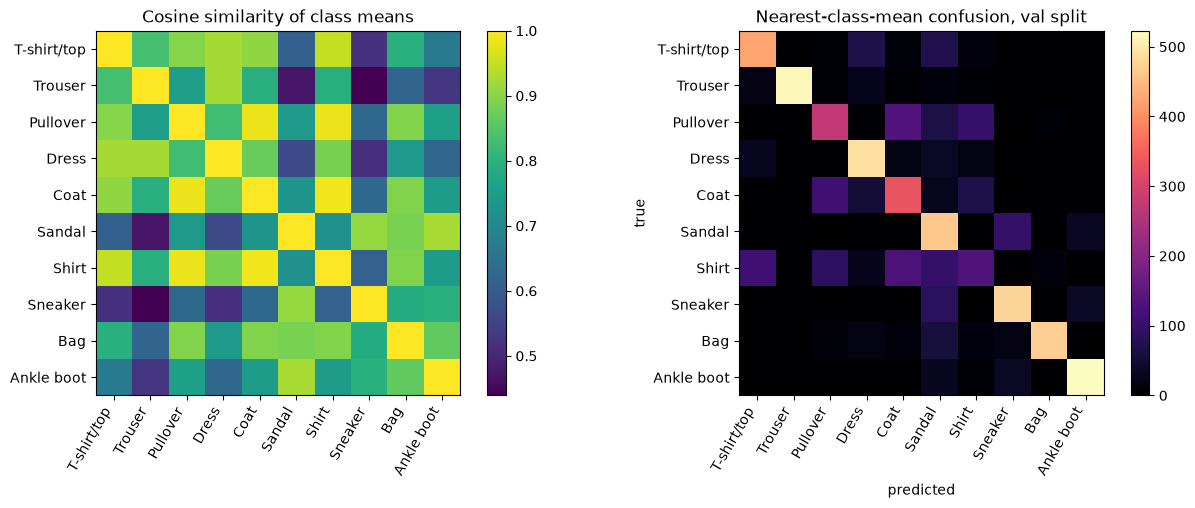

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
first = axes[0].imshow(similarity, cmap="viridis", interpolation="nearest")
axes[0].set_title("Cosine similarity of class means")
second = axes[1].imshow(confusion, cmap="magma", interpolation="nearest")
axes[1].set_title("Nearest-class-mean confusion, val split")
axes[1].set_xlabel("predicted")
axes[1].set_ylabel("true")
for ax, image in zip(axes, (first, second)):
    ax.set_xticks(range(NUM_CLASSES), CLASS_NAMES, rotation=60, ha="right")
    ax.set_yticks(range(NUM_CLASSES), CLASS_NAMES)
    fig.colorbar(image, ax=ax)
save(fig, "class_similarity")
plt.show()

## Data representations

Each model family sees the same image through a different structure. The measurements below
are the evidence for the inductive-bias discussion in the report.

In [12]:
sample = torch.from_numpy(train_pixels[:10000]).float().div(255.0).unsqueeze(1)
patch_size = config["input"]["patch_size"]

for representation in ("image", "rows", "columns", "patches"):
    shape = tuple(to_sequence(sample, representation, patch_size).shape[1:])
    print(f"{representation:<9} {str(shape):<12} per image")

image     (1, 28, 28)  per image
rows      (28, 28)     per image
columns   (28, 28)     per image
patches   (49, 16)     per image


### Flattened pixels

A linear or MLP model treats the 784 pixels as unordered features. PCA shows how much of the
variance a purely global view captures, and how much the classes already overlap in it.

In [13]:
from sklearn.decomposition import PCA

flat = train_pixels.reshape(len(train_pixels), -1) / 255.0
pca = PCA(n_components=100, random_state=config["seed"]).fit(flat[:10000])
cumulative = np.cumsum(pca.explained_variance_ratio_)
for k in (10, 50, 100):
    print(f"first {k:>3} components explain {cumulative[k - 1]:.1%} of pixel variance")

first  10 components explain 72.1% of pixel variance
first  50 components explain 86.4% of pixel variance
first 100 components explain 91.4% of pixel variance


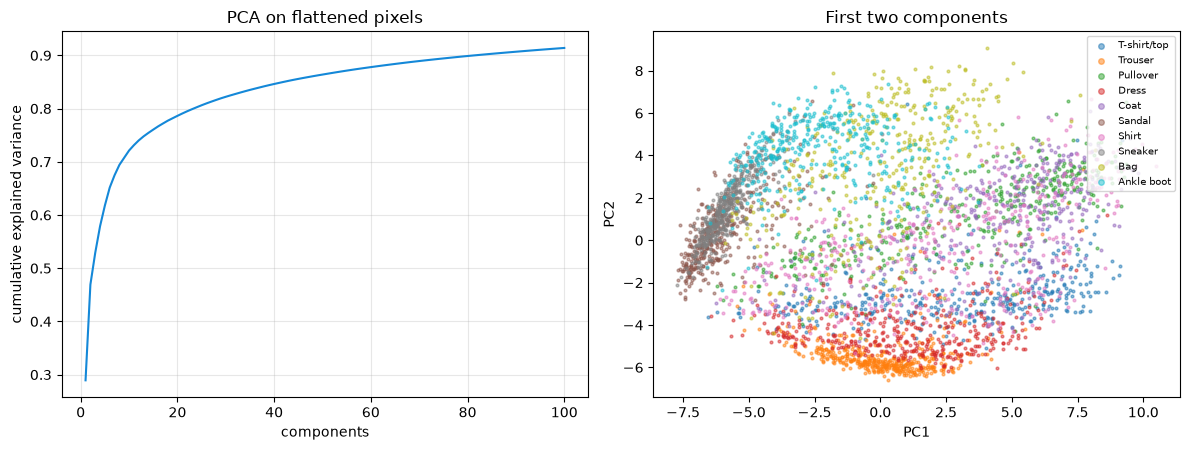

In [14]:
projected = pca.transform(flat[:4000])[:, :2]
subset_labels = train_labels[:4000]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
axes[0].plot(np.arange(1, 101), cumulative, color="#1488D8")
axes[0].set_xlabel("components")
axes[0].set_ylabel("cumulative explained variance")
axes[0].set_title("PCA on flattened pixels")
axes[0].grid(alpha=0.3)
for label in range(NUM_CLASSES):
    mask = subset_labels == label
    axes[1].scatter(projected[mask, 0], projected[mask, 1], s=4, alpha=0.5, label=CLASS_NAMES[label])
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].set_title("First two components")
axes[1].legend(fontsize=7, markerscale=2, loc="upper right")
save(fig, "pca")
plt.show()

### Spatial structure

A convolution assumes that nearby pixels are related. Correlation as a function of pixel
distance measures whether that assumption holds here.

In [15]:
columns = flat[:10000]
correlation = np.nan_to_num(np.corrcoef(columns, rowvar=False))
grid = np.stack(np.meshgrid(np.arange(28), np.arange(28), indexing="ij"), axis=-1).reshape(-1, 2)
distance = np.sqrt(((grid[:, None] - grid[None]) ** 2).sum(-1))

bins = np.arange(1, 21)
profile = np.array([correlation[(distance >= d - 0.5) & (distance < d + 0.5)].mean() for d in bins])
for d in (1, 2, 5, 10, 20):
    print(f"mean correlation at distance {d:>2}px: {profile[d - 1]:.3f}")

mean correlation at distance  1px: 0.747
mean correlation at distance  2px: 0.598
mean correlation at distance  5px: 0.362
mean correlation at distance 10px: 0.159
mean correlation at distance 20px: 0.093


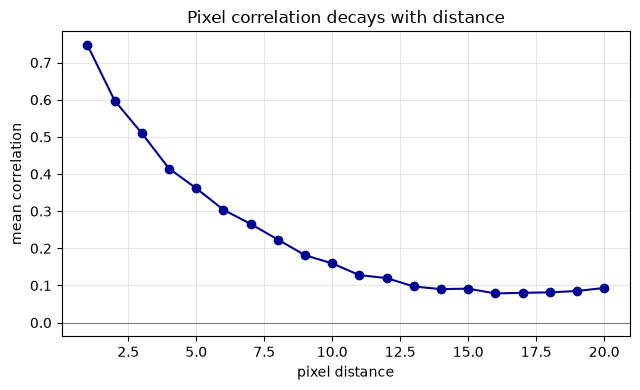

In [16]:
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(bins, profile, marker="o", color="#030391")
ax.axhline(0, color="grey", linewidth=0.8)
ax.set_xlabel("pixel distance")
ax.set_ylabel("mean correlation")
ax.set_title("Pixel correlation decays with distance")
ax.grid(alpha=0.3)
save(fig, "spatial_correlation")
plt.show()

### Row, column, and patch sequences

Recurrent and Transformer models read the image as a sequence. The profiles show how much
signal each timestep carries, which is what makes the choice of representation matter.

In [17]:
rows = to_sequence(sample, "rows").numpy()
cols = to_sequence(sample, "columns").numpy()
patches = to_sequence(sample, "patches", patch_size).numpy()

row_std, col_std = rows.std(axis=(0, 2)), cols.std(axis=(0, 2))
patch_std = patches.std(axis=(0, 2)).reshape(28 // patch_size, 28 // patch_size)

def profile(name, shape, std):
    weak = (std < 0.25 * std.max()).sum()
    print(f"{name:<9}{shape[1]:>3} steps x {shape[2]:>3} features   std {std.min():.3f} to {std.max():.3f}   {weak} below 25% of peak")


profile("rows", rows.shape, row_std)
profile("columns", cols.shape, col_std)
profile("patches", patches.shape, patch_std.ravel())

rows      28 steps x  28 features   std 0.174 to 0.366   0 below 25% of peak
columns   28 steps x  28 features   std 0.067 to 0.365   1 below 25% of peak
patches   49 steps x  16 features   std 0.024 to 0.373   3 below 25% of peak


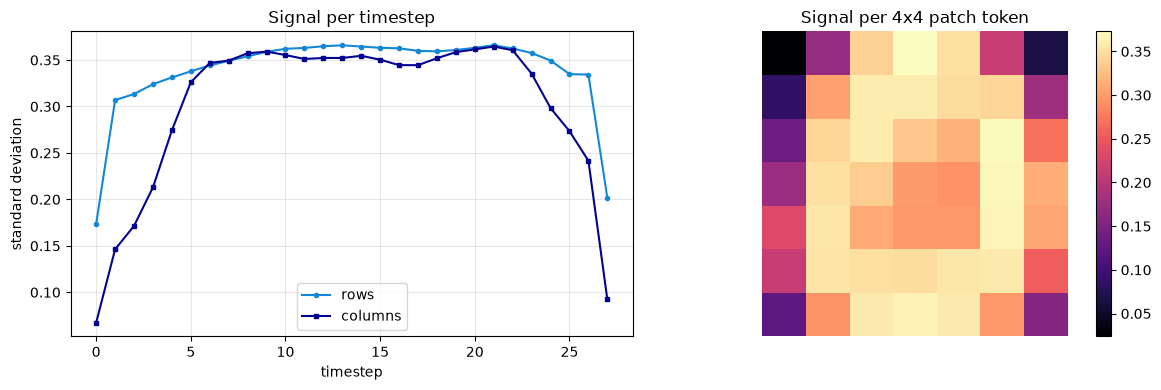

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(row_std, label="rows", color="#1488D8", marker="o", markersize=3)
axes[0].plot(col_std, label="columns", color="#030391", marker="s", markersize=3)
axes[0].set_xlabel("timestep")
axes[0].set_ylabel("standard deviation")
axes[0].set_title("Signal per timestep")
axes[0].legend()
axes[0].grid(alpha=0.3)
image = axes[1].imshow(patch_std, cmap="magma", interpolation="nearest")
axes[1].set_title(f"Signal per {patch_size}x{patch_size} patch token")
axes[1].axis("off")
fig.colorbar(image, ax=axes[1])
save(fig, "sequence_profiles")
plt.show()

## Preprocessing and augmentation

The pipeline the models actually receive, taken from `build_dataloaders`, so the numbers here
match the run configuration rather than a separate copy of the logic.

In [19]:
mean, std = normalization_stats(data_dir, split)
loaders = build_dataloaders(config)
images, batch_labels = next(iter(loaders["val"]))

print(f"train-split statistics  mean {mean:.4f}, std {std:.4f}")
print(f"recorded in config      {config['dataset']['normalization']}")
print()
for name, loader in loaders.items():
    print(f"{name:<5} {len(loader.dataset):>6} images, {len(loader):>4} batches of {loader.batch_size}")
print()
print(f"batch images {tuple(images.shape)} {images.dtype} [{images.min():.2f}, {images.max():.2f}]")
print(f"batch labels {tuple(batch_labels.shape)} {batch_labels.dtype} [{batch_labels.min()}, {batch_labels.max()}]")

train-split statistics  mean 0.2858, std 0.3529
recorded in config      {'mean': 0.28579843044281006, 'std': 0.3528536558151245}

train  54000 images,  422 batches of 128
val     6000 images,   47 batches of 128
test   10000 images,   79 batches of 128

batch images (128, 1, 28, 28) torch.float32 [-0.81, 2.02]
batch labels (128,) torch.int64 [0, 9]


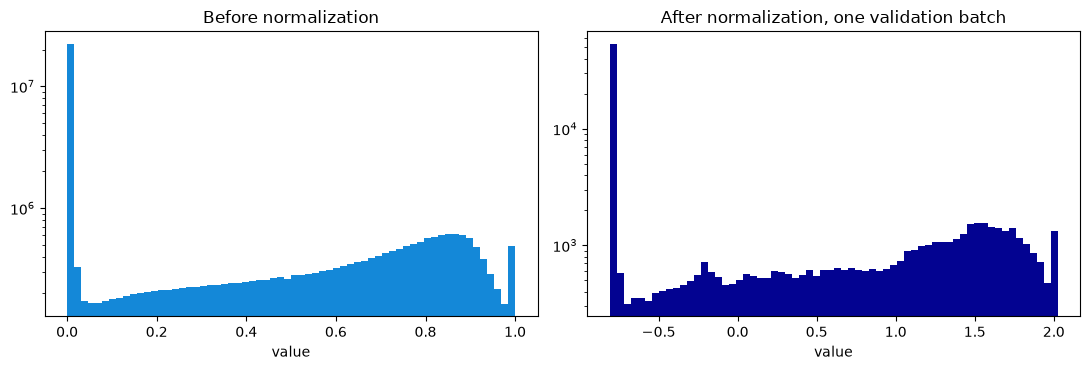

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].hist(scaled.reshape(-1), bins=64, color="#1488D8")
axes[0].set_title("Before normalization")
axes[0].set_xlabel("value")
axes[0].set_yscale("log")
axes[1].hist(images.numpy().reshape(-1), bins=64, color="#030391")
axes[1].set_title("After normalization, one validation batch")
axes[1].set_xlabel("value")
axes[1].set_yscale("log")
save(fig, "normalization")
plt.show()

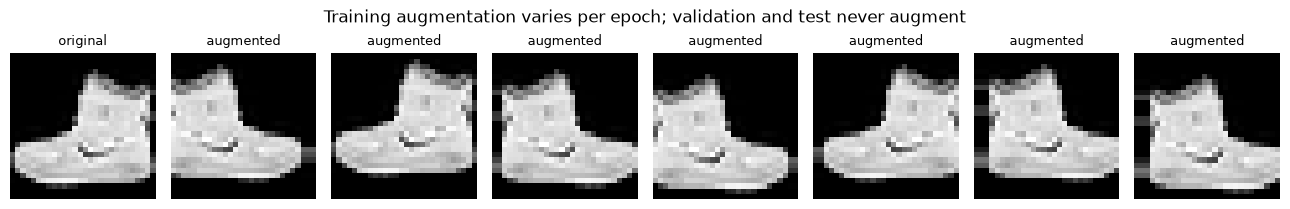

In [21]:
train_subset = loaders["train"].dataset
index = train_subset.indices[0]
augmented = [train_subset.dataset[index][0] for _ in range(7)]
original = torch.from_numpy(train_pixels[0]).float().div(255.0)

fig, axes = plt.subplots(1, 8, figsize=(13, 2.1))
axes[0].imshow(original, cmap="gray", interpolation="nearest")
axes[0].set_title("original", fontsize=9)
for ax, tensor in zip(axes[1:], augmented):
    ax.imshow((tensor.squeeze(0) * std + mean).clamp(0, 1), cmap="gray", interpolation="nearest")
    ax.set_title("augmented", fontsize=9)
for ax in axes:
    ax.axis("off")
fig.suptitle("Training augmentation varies per epoch; validation and test never augment")
save(fig, "augmentation")
plt.show()

## Findings

**The split is balanced and fixed.** 54,000 train, 6,000 validation, 10,000 test, 10% of each
class in validation, max-to-min ratio 1.000 everywhere. Accuracy and macro-F1 therefore
measure the same thing here, and any gap between them comes from the model, not the priors.

**Half the input is background.** 50.2% of training pixels are exactly zero and ink occupies a
centred region, so a flattened 784-feature view spends most of its parameters on pixels that
never vary. This is the cost the linear and MLP models pay.

**Pixels are locally correlated.** Mean correlation falls from 0.747 at one pixel to 0.159 at
ten and 0.093 at twenty. Neighbouring pixels are strongly related and distant ones are nearly
independent, which is exactly the assumption a convolution encodes and the flattened view
discards.

**The flattened view is highly redundant.** Ten principal components already explain 72.1% of
pixel variance and one hundred explain 91.4%. A trivial nearest-class-mean classifier on raw
pixels reaches 68.4% on validation, so that is the floor every required model must clear by a
wide margin.

**One cluster drives the errors.** Coat/Shirt, Pullover/Coat and Pullover/Shirt have cosine
similarity above 0.98, and the baseline recall for Shirt is 0.220 against 0.872 for Ankle boot.
Per-class F1 and the confusion matrix, not accuracy alone, are what will separate the models.

**Sequence length and token width trade off.** Rows and columns give 28 steps of 28 features,
patches give 49 tokens of 16. No row falls below a quarter of peak signal, against one column
and three patch tokens, so patch tokenisation isolates background into a few weak tokens while
row and column sequences spread it across every step.

**Preprocessing is fixed and recorded.** Normalization uses train-split statistics only
(mean 0.2858, std 0.3529), written into the run configuration; augmentation applies to the
training loader only, so validation and test stay deterministic across models.